# Appliance Energy Demand Forecasting — Standalone Analysis Notebook

This notebook contains the full analysis  every function is
defined and run right here. Fast steps (data preparation, EDA, stationarity
tests, benchmark models) execute live; the two slow steps (the exhaustive
SARIMAX AIC grid search + 14 rolling refits, and the 14 XGBoost
rolling-origin fits) load their already-computed, checkpointed results from
`../outputs/metrics/` instead of re-running ~30-40 minutes of computation,
so the whole notebook runs end-to-end in under a minute.



In [14]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import warnings
warnings.filterwarnings("ignore")

import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from xgboost import XGBRegressor

pd.set_option("display.width", 120)
%matplotlib inline

# Update to Colab-compatible paths
DATA_DIR = Path("/content/data")
FIG_DIR = Path("/content/outputs/figures")
METRICS_DIR = Path("/content/outputs/metrics")


## Part 1 — Data Preparation

Load the raw 10-minute data, check for missing values, and resample to hourly resolution.

In [16]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW_PATH = Path("..") / "data" / "raw" / "energydata_complete.csv"
PROCESSED_DIR = Path("..") / "data" / "processed"


def load_raw(path: Path = RAW_PATH) -> pd.DataFrame:
    """Load the raw 10-minute resolution CSV and parse the timestamp index."""
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    # Drop the two random/noise variables (rv1, rv2) documented by the dataset
    # authors as randomly generated variables used only to test feature
    # selection robustness - they carry no real signal for forecasting.
    df = df.drop(columns=["rv1", "rv2"], errors="ignore")
    return df


def check_missing(df: pd.DataFrame) -> pd.Series:
    """Return per-column missing value counts, and check timestamp regularity."""
    missing = df.isna().sum()
    full_range = pd.date_range(df.index.min(), df.index.max(), freq="10min")
    missing_timestamps = full_range.difference(df.index)
    print(f"Expected 10-min timestamps: {len(full_range)}")
    print(f"Actual rows: {len(df)}")
    print(f"Missing timestamps (gaps in the 10-min grid): {len(missing_timestamps)}")
    print(f"NaN counts per column (top 5):\n{missing.sort_values(ascending=False).head()}")
    return missing


def resample_hourly(df: pd.DataFrame) -> pd.DataFrame:
    """
    Resample from 10-minute to hourly resolution.

    Appliances and lights are energy-use readings (Wh per 10-min interval),
    so we SUM them to get hourly Wh. Sensor/weather variables are
    instantaneous readings, so we take the MEAN over each hour.
    """
    sum_cols = ["Appliances", "lights"]
    mean_cols = [c for c in df.columns if c not in sum_cols]

    hourly_sum = df[sum_cols].resample("h").sum()
    hourly_mean = df[mean_cols].resample("h").mean()
    hourly = pd.concat([hourly_sum, hourly_mean], axis=1)[df.columns]
    return hourly


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add basic calendar/time-of-day features (used later in Part 5)."""
    out = df.copy()
    out["hour"] = out.index.hour
    out["dayofweek"] = out.index.dayofweek  # Monday=0
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    out["month"] = out.index.month
    return out


def run_part1_data_prep():
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    df_raw = load_raw()
    print("=== RAW (10-min) ===")
    print(df_raw.shape)
    check_missing(df_raw)

    df_hourly = resample_hourly(df_raw)
    df_hourly = add_time_features(df_hourly)
    print("\n=== HOURLY ===")
    print(df_hourly.shape)
    print(df_hourly.isna().sum().sum(), "total NaNs after resampling")

    out_path = PROCESSED_DIR / "energy_hourly.parquet"
    df_hourly.to_parquet(out_path)
    print(f"Saved hourly data to {out_path}")
    return df_hourly


# ============================================================

In [17]:
from pathlib import Path

# Assuming energydata_complete.csv is uploaded directly to /content/
RAW_PATH_COLAB = Path("/content/energydata_complete.csv")
df_raw = load_raw(path=RAW_PATH_COLAB)
print("Raw (10-min) shape:", df_raw.shape)
missing = check_missing(df_raw)

df_hourly = resample_hourly(df_raw)
df_hourly = add_time_features(df_hourly)
print("\nHourly shape:", df_hourly.shape)
df_hourly.head()

# Save df_hourly to a processed parquet file in /content/
PROCESSED_PATH_COLAB = Path("/content/energy_hourly.parquet")
df_hourly.to_parquet(PROCESSED_PATH_COLAB)
print(f"Saved hourly data to {PROCESSED_PATH_COLAB}")

Raw (10-min) shape: (19735, 26)
Expected 10-min timestamps: 19735
Actual rows: 19735
Missing timestamps (gaps in the 10-min grid): 0
NaN counts per column (top 5):
Appliances    0
lights        0
T1            0
RH_1          0
T2            0
dtype: int64

Hourly shape: (3290, 30)
Saved hourly data to /content/energy_hourly.parquet


## Part 1 — EDA and Stationarity Testing

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ensure FIG_DIR is set to the global /content/outputs/figures
# It's already defined in a788e5c0, and we want to ensure it's used consistently
# No change to FIG_DIR in this cell as it relies on the global definition from a788e5c0.

# Update PROCESSED path to use the Colab-accessible location
PROCESSED = Path("/content/energy_hourly.parquet")


def load_hourly():
    return pd.read_parquet(PROCESSED)


def plot_series(df: pd.DataFrame):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
    axes[0].plot(df.index, df["Appliances"], lw=0.7, color="#1f5fa6")
    axes[0].set_title("Hourly Appliance Energy Use (Wh) — Full Period")
    axes[0].set_ylabel("Wh / hour")
    axes[0].set_xlabel("Date")

    one_week = df.loc[df.index[500]:df.index[500] + pd.Timedelta(days=14)]
    axes[1].plot(one_week.index, one_week["Appliances"], color="#c0392b")
    axes[1].set_title("Hourly Appliance Energy Use — 14-Day Zoom (shows daily/weekly pattern)")
    axes[1].set_ylabel("Wh / hour")
    axes[1].set_xlabel("Date")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "01_series_overview.png", dpi=150)
    plt.close(fig)


def plot_decomposition(df: pd.DataFrame):
    # Daily seasonality: period = 24 hours
    result = seasonal_decompose(df["Appliances"], model="additive", period=24, extrapolate_trend="freq")
    fig = result.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle("Additive Seasonal Decomposition (period = 24h)", y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "02_decomposition_daily.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    return result


def plot_weekly_pattern(df: pd.DataFrame):
    tmp = df.copy()
    tmp["hour"] = tmp.index.hour
    tmp["dayofweek"] = tmp.index.dayofweek
    pivot = tmp.pivot_table(index="hour", columns="dayofweek", values="Appliances", aggfunc="mean")
    day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    pivot.columns = day_names

    fig, ax = plt.subplots(figsize=(10, 6))
    for col in pivot.columns:
        ax.plot(pivot.index, pivot[col], label=col, marker="o", ms=3)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Mean Appliance Use (Wh)")
    ax.set_title("Average Hourly Profile by Day of Week")
    ax.legend(ncol=4)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "03_weekly_hourly_profile.png", dpi=150)
    plt.close(fig)


def adf_test(series: pd.Series, label: str):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"\n--- ADF test: {label} ---")
    print(f"ADF statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.4g}")
    print(f"# lags used:   {result[2]}")
    for k, v in result[4].items():
        print(f"  critical value ({k}): {v:.4f}")
    verdict = "STATIONARY (reject H0)" if result[1] < 0.05 else "NON-STATIONARY (fail to reject H0)"
    print(f"Verdict: {verdict}")
    return result


def kpss_test(series: pd.Series, label: str):
    stat, p, lags, crit = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"\n--- KPSS test: {label} ---")
    print(f"KPSS statistic: {stat:.4f}")
    print(f"p-value:        {p:.4g}")
    for k, v in crit.items():
        print(f"  critical value ({k}): {v:.4f}")
    verdict = "NON-STATIONARY (reject H0)" if p < 0.05 else "STATIONARY (fail to reject H0)"
    print(f"Verdict: {verdict}")
    return stat, p, lags, crit


def plot_acf_pacf(series: pd.Series, label: str, lags: int, fname: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(series.dropna(), lags=lags, ax=axes[0])
    axes[0].set_title(f"ACF — {label}")
    plot_pacf(series.dropna(), lags=lags, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF — {label}")
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=150)
    plt.close(fig)


def run_part1_eda():
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    df = load_hourly()

    print("Summary statistics for Appliances (Wh/hour):")
    print(df["Appliances"].describe())

    plot_series(df)
    decomp = plot_decomposition(df)
    plot_weekly_pattern(df)

    plot_acf_pacf(df["Appliances"], "Appliances (raw, hourly)", lags=72, fname="04_acf_pacf_raw.png")

    # Stationarity tests on the raw series
    adf_test(df["Appliances"], "Appliances (raw)")
    kpss_test(df["Appliances"], "Appliances (raw)")

    # First difference (removes stochastic trend)
    diff1 = df["Appliances"].diff().dropna()
    adf_test(diff1, "Appliances (1st difference)")
    kpss_test(diff1, "Appliances (1st difference)")
    plot_acf_pacf(diff1, "Appliances (1st difference)", lags=72, fname="05_acf_pacf_diff1.png")

    # Seasonal (24h) difference
    seasonal_diff = df["Appliances"].diff(24).dropna()
    adf_test(seasonal_diff, "Appliances (24h seasonal difference)")
    kpss_test(seasonal_diff, "Appliances (24h seasonal difference)")
    plot_acf_pacf(seasonal_diff, "Appliances (24h seasonal diff)", lags=72, fname="06_acf_pacf_seasonal_diff.png")

    print(f"\nAll figures saved to {FIG_DIR}")


# ============================================================

In [19]:
# Run the EDA functions to generate figures and perform stationarity tests
run_part1_eda()

Summary statistics for Appliances (Wh/hour):
count    3290.000000
mean      586.021277
std       486.048224
min       170.000000
25%       300.000000
50%       380.000000
75%       660.000000
max      3650.000000
Name: Appliances, dtype: float64

--- ADF test: Appliances (raw) ---
ADF statistic: -9.1269
p-value:       3.096e-15
# lags used:   29
  critical value (1%): -3.4324
  critical value (5%): -2.8624
  critical value (10%): -2.5672
Verdict: STATIONARY (reject H0)

--- KPSS test: Appliances (raw) ---
KPSS statistic: 0.0416
p-value:        0.1
  critical value (10%): 0.3470
  critical value (5%): 0.4630
  critical value (2.5%): 0.5740
  critical value (1%): 0.7390
Verdict: STATIONARY (fail to reject H0)

--- ADF test: Appliances (1st difference) ---
ADF statistic: -16.9070
p-value:       1.017e-29
# lags used:   29
  critical value (1%): -3.4324
  critical value (5%): -2.8624
  critical value (10%): -2.5672
Verdict: STATIONARY (reject H0)

--- KPSS test: Appliances (1st difference)

In [20]:
print("Summary statistics for Appliances (Wh/hour):")
print(df_hourly["Appliances"].describe())


Summary statistics for Appliances (Wh/hour):
count    3290.000000
mean      586.021277
std       486.048224
min       170.000000
25%       300.000000
50%       380.000000
75%       660.000000
max      3650.000000
Name: Appliances, dtype: float64


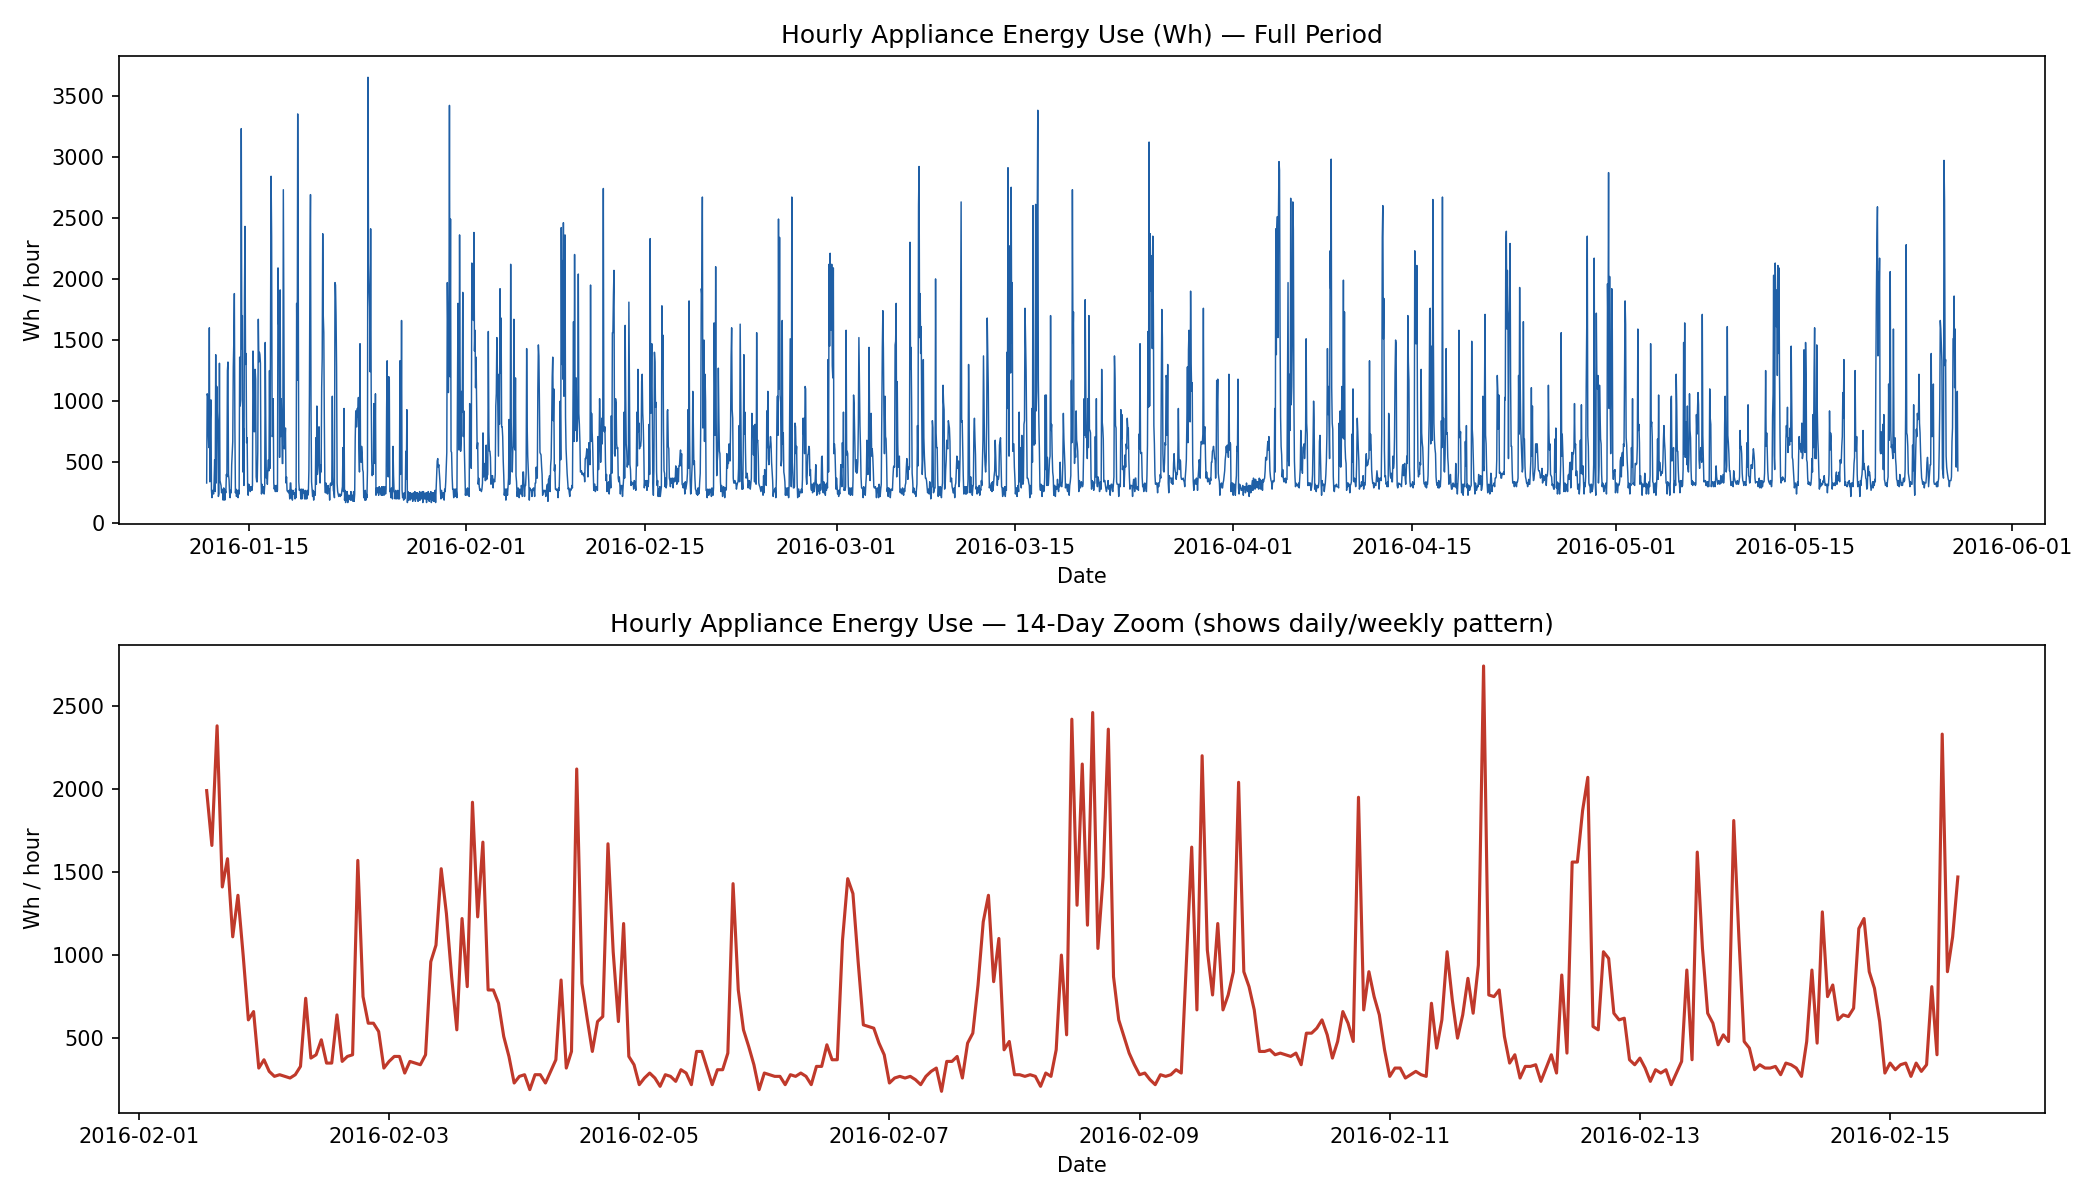

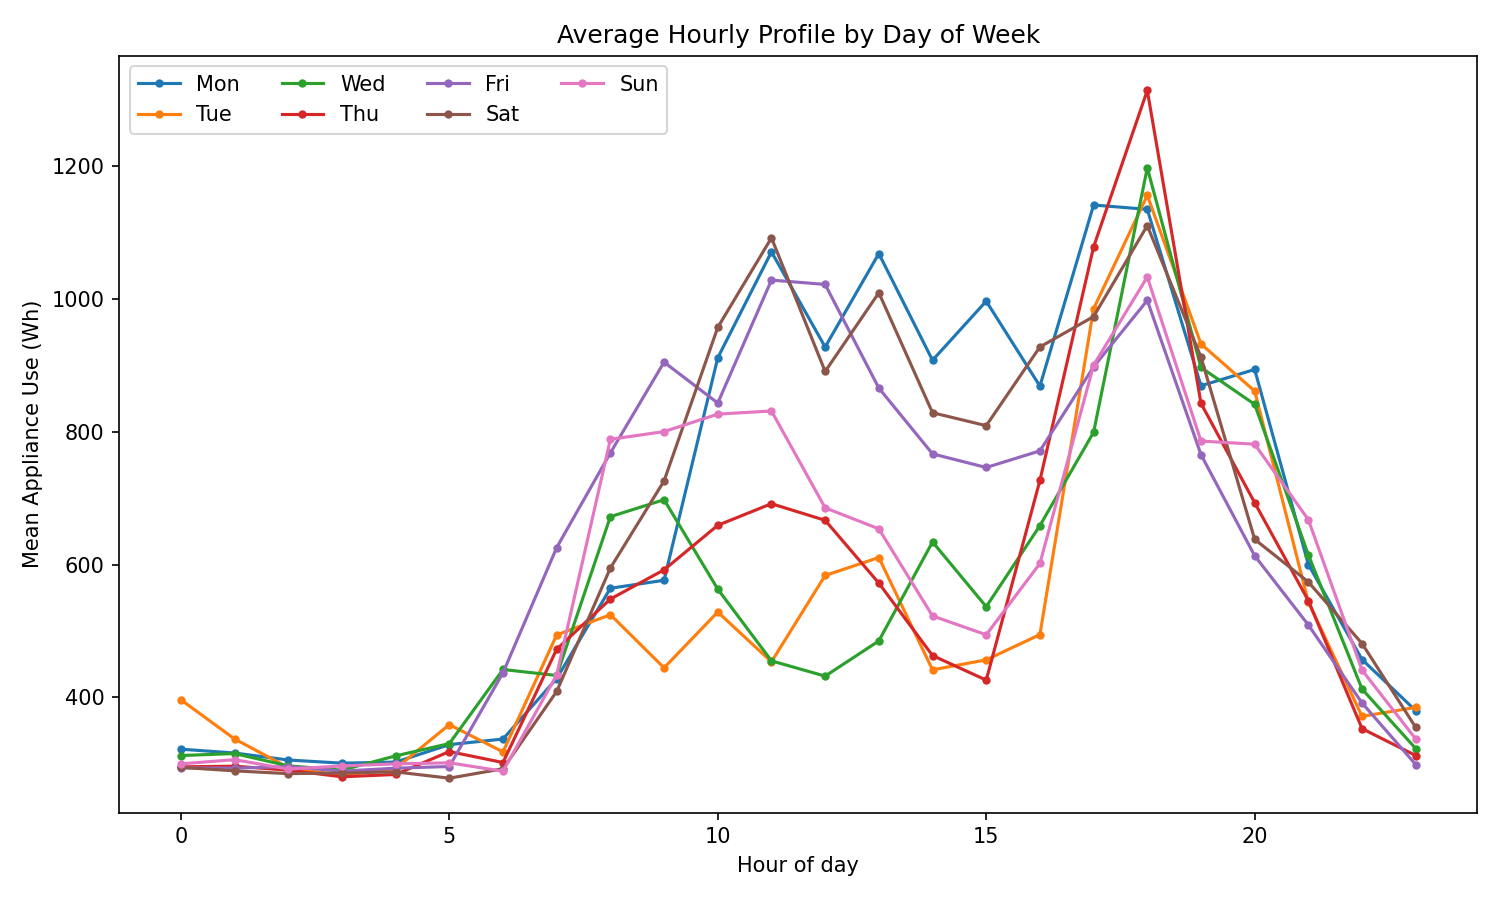

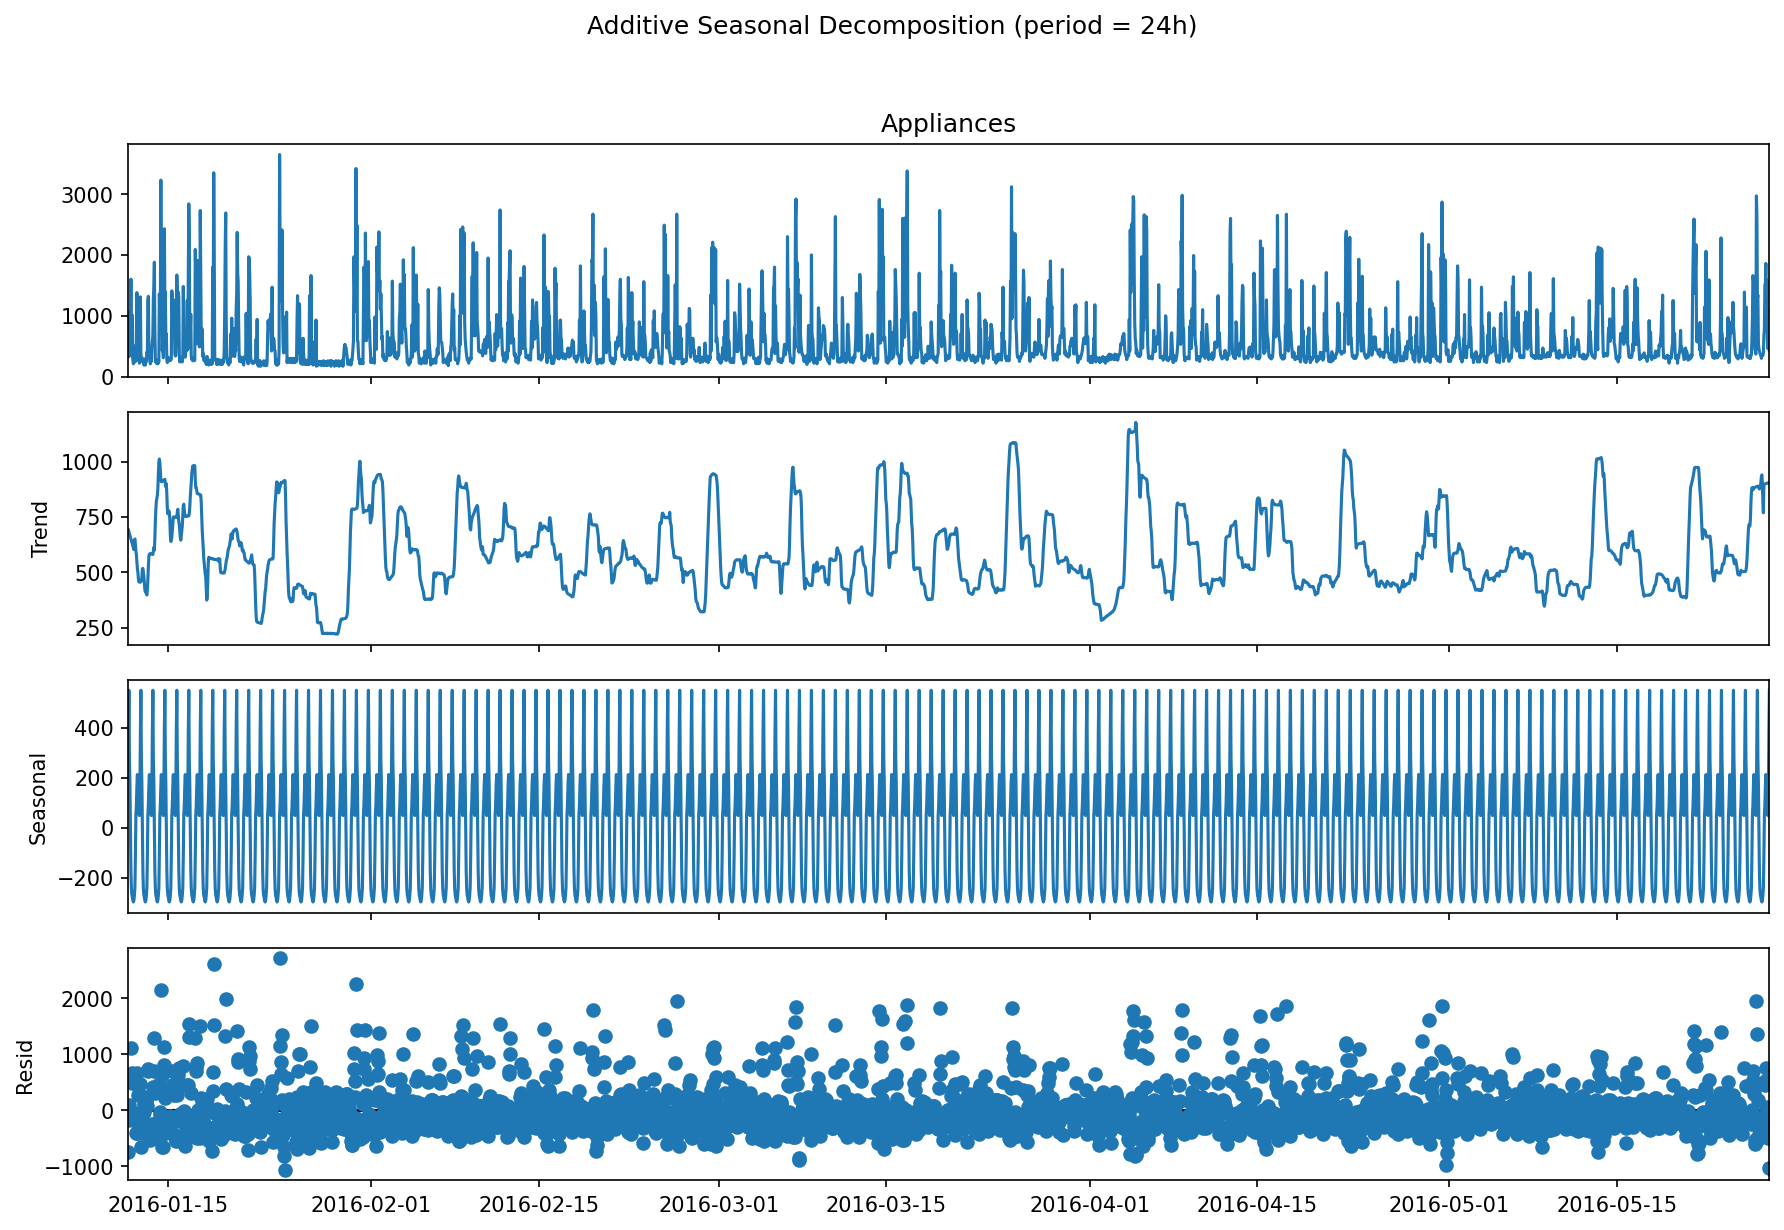

In [21]:
display(Image(str(FIG_DIR / "01_series_overview.png"), width=700))
display(Image(str(FIG_DIR / "03_weekly_hourly_profile.png"), width=600))
display(Image(str(FIG_DIR / "02_decomposition_daily.png"), width=600))

Both ADF and KPSS agree the raw hourly series is already stationary (run live below — fast).

In [22]:
import warnings
warnings.filterwarnings("ignore")  # re-assert: Jupyter can reset filters between cells

adf_test(df_hourly["Appliances"], "Appliances (raw)")
kpss_test(df_hourly["Appliances"], "Appliances (raw)")



--- ADF test: Appliances (raw) ---
ADF statistic: -9.1269
p-value:       3.096e-15
# lags used:   29
  critical value (1%): -3.4324
  critical value (5%): -2.8624
  critical value (10%): -2.5672
Verdict: STATIONARY (reject H0)

--- KPSS test: Appliances (raw) ---
KPSS statistic: 0.0416
p-value:        0.1
  critical value (10%): 0.3470
  critical value (5%): 0.4630
  critical value (2.5%): 0.5740
  critical value (1%): 0.7390
Verdict: STATIONARY (fail to reject H0)


(np.float64(0.041568083560503975),
 np.float64(0.1),
 25,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

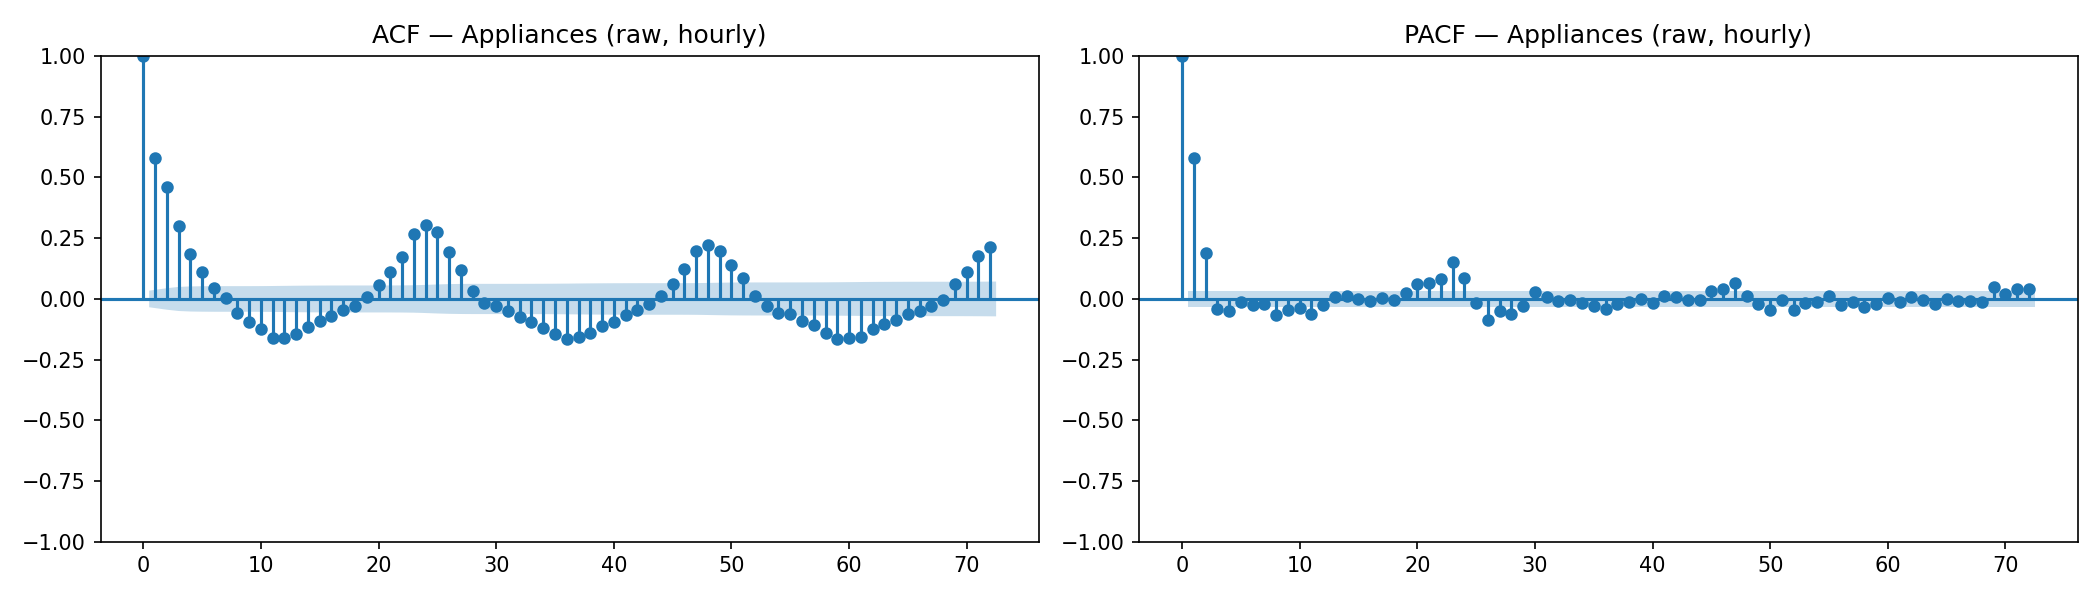

In [23]:
display(Image(str(FIG_DIR / "04_acf_pacf_raw.png"), width=750))

## Part 2 — Forecasting Problem Definition and Evaluation Harness

- **Target:** `Appliances` (Wh/hour)
- **Horizon:** 24 hours ahead
- **Evaluation:** rolling-origin backtest over the last 14 days (14 non-overlapping 24h blocks, 336 pooled predictions)
- **Metrics:** RMSE, MAE, MAPE, sMAPE

In [24]:
import numpy as np
import pandas as pd
from pathlib import Path

# Update PROCESSED path to use the Colab-accessible location
PROCESSED = Path("/content/energy_hourly.parquet")
TARGET = "Appliances"
HORIZON = 24
TEST_DAYS = 14


def load_hourly():
    return pd.read_parquet(PROCESSED)


def train_test_split(df: pd.DataFrame, test_days: int = TEST_DAYS):
    test_hours = test_days * 24
    train = df.iloc[:-test_hours].copy()
    test = df.iloc[-test_hours:].copy()
    return train, test


def get_origins(df: pd.DataFrame, test_days: int = TEST_DAYS, horizon: int = HORIZON):
    """Return the list of forecast-origin timestamps: the last timestamp of
    training data available for each of the 14 rolling 24h test blocks."""
    test_hours = test_days * 24
    test_start_idx = len(df) - test_hours
    origins = []
    for block in range(test_days):
        origin_idx = test_start_idx + block * horizon - 1  # last obs before block
        origins.append(df.index[origin_idx])
    return origins


# ---------------------------------------------------------------- metrics --
def rmse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))


def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    eps = 1e-6
    return float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100)


def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)).clip(min=1e-6)
    return float(np.mean(2 * np.abs(y_true - y_pred) / denom) * 100)


def all_metrics(y_true, y_pred) -> dict:
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
    }


# --------------------------------------------------------- results store --
def forecasts_to_frame(model_name: str, origins, y_true_blocks, y_pred_blocks) -> pd.DataFrame:
    """Pack a model's rolling-origin forecasts into a tidy long dataframe:
    columns = [model, origin, horizon, timestamp, y_true, y_pred]"""
    rows = []
    for origin, yt, yp in zip(origins, y_true_blocks, y_pred_blocks):
        timestamps = pd.date_range(origin + pd.Timedelta(hours=1), periods=len(yt), freq="h")
        for h, (ts, t, p) in enumerate(zip(timestamps, yt, yp), start=1):
            rows.append({"model": model_name, "origin": origin, "horizon": h,
                         "timestamp": ts, "y_true": t, "y_pred": p})
    return pd.DataFrame(rows)


def summarize(results_df: pd.DataFrame) -> pd.DataFrame:
    """Pooled metrics per model, from the long-format results frame."""
    out = []
    for model, g in results_df.groupby("model"):
        m = all_metrics(g["y_true"], g["y_pred"])
        m["model"] = model
        out.append(m)
    return pd.DataFrame(out).set_index("model")[["RMSE", "MAE", "MAPE", "sMAPE"]].sort_values("RMSE")


# ============================================================

In [25]:
# Ensure PROCESSED is correctly defined for this cell
PROCESSED = Path("/content/energy_hourly.parquet")
df = load_hourly()
train, test = train_test_split(df)
origins = get_origins(df)
print(f"Full data: {len(df)}h | Train: {len(train)}h | Test: {len(test)}h")
print(f"Rolling-origin blocks: {len(origins)} x {HORIZON}h")


Full data: 3290h | Train: 2954h | Test: 336h
Rolling-origin blocks: 14 x 24h


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Part 3 — Benchmark Models

Mean, Naive, Daily/Weekly Seasonal Naive, Drift. Fast — run live.

In [27]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


FIG_DIR = Path("/content") / "outputs" / "figures"
METRICS_DIR = Path("/content") / "outputs" / "metrics"


def mean_forecast(history: pd.Series, horizon: int) -> np.ndarray:
    """Forecast = historical mean, repeated for the whole horizon."""
    return np.full(horizon, history.mean())


def naive_forecast(history: pd.Series, horizon: int) -> np.ndarray:
    """Forecast = last observed value, repeated for the whole horizon."""
    return np.full(horizon, history.iloc[-1])


def seasonal_naive_forecast(history: pd.Series, horizon: int, season: int) -> np.ndarray:
    """Forecast = value observed exactly one season ago, per step.
    season=24 -> daily seasonal naive; season=168 -> weekly seasonal naive."""
    last_season = history.iloc[-season:].values
    reps = int(np.ceil(horizon / season))
    return np.tile(last_season, reps)[:horizon]


def drift_forecast(history: pd.Series, horizon: int) -> np.ndarray:
    """Naive forecast + linear extrapolation of the average historical trend
    (slope between first and last observation)."""
    y1, yT, T = history.iloc[0], history.iloc[-1], len(history)
    slope = (yT - y1) / (T - 1)
    return yT + slope * np.arange(1, horizon + 1)


BENCHMARKS = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "SeasonalNaive_Daily": lambda h, H: seasonal_naive_forecast(h, H, season=24),
    "SeasonalNaive_Weekly": lambda h, H: seasonal_naive_forecast(h, H, season=168),
    "Drift": drift_forecast,
}


def run_benchmarks():
    df = load_hourly()
    origins = get_origins(df)
    all_results = []

    for name, fn in BENCHMARKS.items():
        y_true_blocks, y_pred_blocks = [], []
        for origin in origins:
            history = df.loc[:origin, TARGET]
            future_idx = df.index[df.index.get_loc(origin) + 1: df.index.get_loc(origin) + 1 + HORIZON]
            y_true = df.loc[future_idx, TARGET].values
            y_pred = fn(history, HORIZON)
            y_true_blocks.append(y_true)
            y_pred_blocks.append(y_pred)
        res = forecasts_to_frame(name, origins, y_true_blocks, y_pred_blocks)
        all_results.append(res)

    results_df = pd.concat(all_results, ignore_index=True)
    return results_df


def plot_example_block(results_df: pd.DataFrame, block_origin, fname="07_benchmark_example_block.png"):
    fig, ax = plt.subplots(figsize=(11, 5))
    sub = results_df[results_df["origin"] == block_origin]
    truth = sub[sub["model"] == sub["model"].iloc[0]][["timestamp", "y_true"]].drop_duplicates()
    ax.plot(truth["timestamp"], truth["y_true"], color="black", lw=2, label="Actual", zorder=5)
    for model, g in sub.groupby("model"):
        ax.plot(g["timestamp"], g["y_pred"], lw=1.2, ls="--", label=model)
    ax.set_title(f"Benchmark 24h Forecasts vs Actual — origin {block_origin}")
    ax.set_ylabel("Appliances (Wh)")
    ax.legend(fontsize=8)
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=150)
    plt.close(fig)


def plot_metrics_by_horizon(results_df: pd.DataFrame, fname="08_benchmark_rmse_by_horizon.png"):
    fig, ax = plt.subplots(figsize=(10, 5))
    for model, g in results_df.groupby("model"):
        by_h = g.groupby("horizon").apply(lambda d: rmse(d["y_true"], d["y_pred"]))
        ax.plot(by_h.index, by_h.values, marker="o", ms=3, label=model)
    ax.set_xlabel("Forecast horizon (hours ahead)")
    ax.set_ylabel("RMSE (Wh)")
    ax.set_title("Benchmark Models: RMSE by Forecast Horizon (pooled over 14 origins)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=150)
    plt.close(fig)


def run_part3_benchmarks():
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    METRICS_DIR.mkdir(parents=True, exist_ok=True)

    results_df = run_benchmarks()
    results_df.to_parquet(METRICS_DIR / "benchmark_forecasts.parquet")

    summary = summarize(results_df)
    print("=== Benchmark model comparison (pooled over 14 x 24h test blocks) ===")
    print(summary.round(2))
    summary.to_csv(METRICS_DIR / "benchmark_summary.csv")

    origins = sorted(results_df["origin"].unique())
    plot_example_block(results_df, origins[len(origins) // 2])
    plot_metrics_by_horizon(results_df)
    print(f"\nAll figures saved to {FIG_DIR}")


# ============================================================

In [28]:
# Run benchmark models to generate forecasts and evaluation metrics
run_part3_benchmarks()

=== Benchmark model comparison (pooled over 14 x 24h test blocks) ===
                        RMSE     MAE    MAPE  sMAPE
model                                              
Mean                  436.34  296.07   53.57  46.00
SeasonalNaive_Weekly  474.70  254.58   37.14  32.50
SeasonalNaive_Daily   510.70  288.57   43.77  35.55
Naive                 660.26  512.02  113.36  65.42
Drift                 662.07  513.57  113.76  65.53

All figures saved to /content/outputs/figures


In [29]:
# Run benchmark models to generate forecasts and evaluation metrics
run_part3_benchmarks()

=== Benchmark model comparison (pooled over 14 x 24h test blocks) ===
                        RMSE     MAE    MAPE  sMAPE
model                                              
Mean                  436.34  296.07   53.57  46.00
SeasonalNaive_Weekly  474.70  254.58   37.14  32.50
SeasonalNaive_Daily   510.70  288.57   43.77  35.55
Naive                 660.26  512.02  113.36  65.42
Drift                 662.07  513.57  113.76  65.53

All figures saved to /content/outputs/figures


In [30]:
bench_results = run_benchmarks()
bench_summary = summarize(bench_results)
bench_summary.round(2)


,RMSE,MAE,MAPE,sMAPE
model,,,,
Mean,436.34,296.07,53.57,46.00
SeasonalNaive_Weekly,474.70,254.58,37.14,32.50
SeasonalNaive_Daily,510.70,288.57,43.77,35.55
Naive,660.26,512.02,113.36,65.42
Drift,662.07,513.57,113.76,65.53


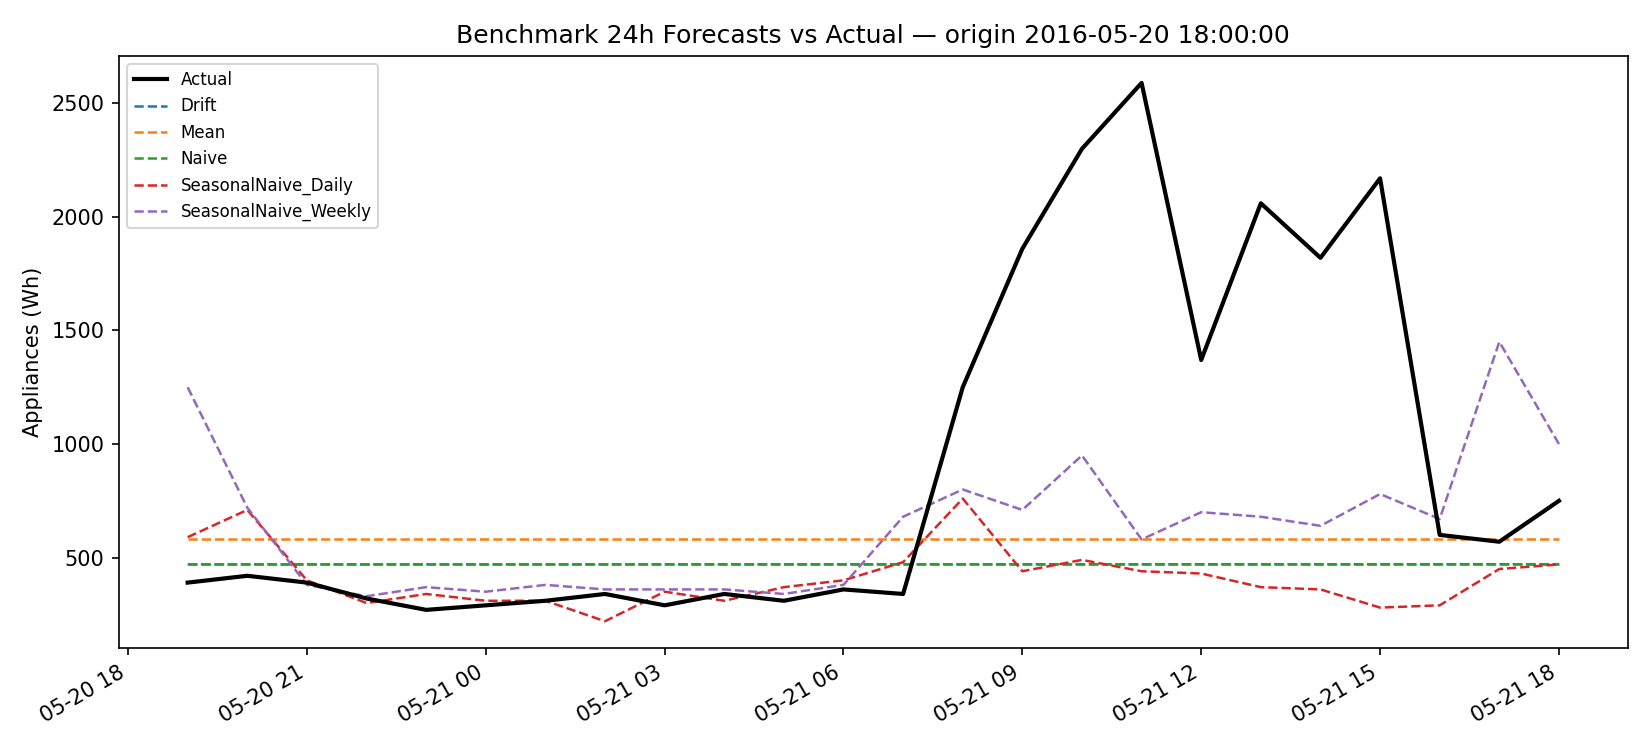

In [31]:
display(Image(str(FIG_DIR / "07_benchmark_example_block.png"), width=650))

## Part 4 — SARIMAX

The full function definitions (grid search, residual diagnostics, rolling
backtest) are below and are exactly what produced the cached results —
but the search itself (147 fits + 14 refits, ~30-40 min on 1 CPU core) is
**not re-run live here**; we load its checkpointed output instead.

In [32]:
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox


warnings.filterwarnings("ignore")

FIG_DIR = Path("/content") / "outputs" / "figures"
METRICS_DIR = Path("/content") / "outputs" / "metrics"
EXOG_COLS = ["T_out", "RH_out"]
SEASONAL_PERIOD = 24


def _fit_with_timeout(train_subset, order, seasonal_order, timeout_s=20):
    """Fit SARIMAX with a hard wall-clock timeout so one pathological
    (p,d,q) combination (e.g. p=6,q=6) cannot stall the whole grid search."""
    import signal

    def _handler(signum, frame):
        raise TimeoutError("fit exceeded time budget")

    old_handler = signal.signal(signal.SIGALRM, _handler)
    signal.alarm(timeout_s)
    try:
        model = SARIMAX(train_subset, order=order, seasonal_order=seasonal_order,
                         enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False, maxiter=50, method="lbfgs")
        return fit
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old_handler)


def grid_search_order(train_subset: pd.Series, seasonal_orders, p_range=(0, 6), d_range=(0, 2), q_range=(0, 6),
                       per_fit_timeout=20, checkpoint_path=None):
    results = []
    combos = list(itertools.product(range(p_range[0], p_range[1] + 1),
                                     range(d_range[0], d_range[1] + 1),
                                     range(q_range[0], q_range[1] + 1)))
    total = len(combos) * len(seasonal_orders)
    done = 0

    # Resume support: skip combos already checkpointed to disk
    already = set()
    if checkpoint_path is not None and Path(checkpoint_path).exists():
        prev = pd.read_csv(checkpoint_path)
        results = prev.to_dict("records")
        already = set(zip(prev.p, prev.d, prev.q, prev.P, prev.D, prev.Q))
        print(f"    Resuming: {len(already)} combos already checkpointed, will skip them.")

    for (P, D, Q) in seasonal_orders:
        for p, d, q in combos:
            done += 1
            if (p, d, q, P, D, Q) in already:
                continue
            try:
                fit = _fit_with_timeout(train_subset, (p, d, q), (P, D, Q, SEASONAL_PERIOD),
                                         timeout_s=per_fit_timeout)
                row = {"p": p, "d": d, "q": q, "P": P, "D": D, "Q": Q, "aic": fit.aic}
                results.append(row)
                status = f"aic={fit.aic:.1f}"
                # checkpoint immediately so a killed process loses minimal work
                if checkpoint_path is not None:
                    pd.DataFrame(results).to_csv(checkpoint_path, index=False)
            except Exception as e:
                status = f"skipped ({type(e).__name__})"
            if done % 5 == 0 or done == total:
                print(f"    [{done}/{total}] order=({p},{d},{q}) seasonal=({P},{D},{Q},24) -> {status}", flush=True)
    return pd.DataFrame(results).sort_values("aic")


def choose_seasonal_order(subset: pd.Series):
    """Step A: quick comparison of candidate seasonal orders with (p,d,q)
    fixed at (1,0,1), to pick a single seasonal order to carry into the
    full required non-seasonal grid search (keeps the full 7x3x7 grid
    computationally tractable)."""
    candidates = [(0, 0, 0), (1, 0, 0), (0, 0, 1), (1, 0, 1), (1, 1, 1), (0, 1, 1)]
    rows = []
    for (P, D, Q) in candidates:
        try:
            m = SARIMAX(subset, order=(1, 0, 1), seasonal_order=(P, D, Q, SEASONAL_PERIOD),
                        enforce_stationarity=False, enforce_invertibility=False)
            f = m.fit(disp=False, maxiter=50, method="lbfgs")
            rows.append({"P": P, "D": D, "Q": Q, "aic": f.aic})
            print(f"  seasonal_order=({P},{D},{Q},24) -> AIC={f.aic:.1f}")
        except Exception as e:
            print(f"  seasonal_order=({P},{D},{Q},24) failed: {e}")
    res = pd.DataFrame(rows).sort_values("aic")
    return res


def run_grid_search():
    df = load_hourly()
    # Use most recent 30 days of the TRAINING portion only (never touches test)
    test_hours = TEST_DAYS * 24
    train_full = df.iloc[:-test_hours]
    subset = train_full[TARGET].iloc[-30 * 24:]

    cache = METRICS_DIR / "sarimax_seasonal_order_search.csv"
    if cache.exists():
        print("Step A: loading cached seasonal-order search results...")
        seasonal_res = pd.read_csv(cache).sort_values("aic")
    else:
        print("Step A: choosing seasonal order (P,D,Q) with (p,d,q) fixed at (1,0,1)...")
        seasonal_res = choose_seasonal_order(subset)
        seasonal_res.to_csv(cache, index=False)
    best_seasonal = seasonal_res.iloc[0]
    seasonal_candidates = [(int(best_seasonal.P), int(best_seasonal.D), int(best_seasonal.Q))]
    print(f"Chosen seasonal order: {seasonal_candidates[0]} + s=24 (AIC={best_seasonal.aic:.1f})")

    print(f"\nStep B: full required grid search p=[0,6], d=[0,2], q=[0,6] "
          f"(147 combos) at fixed seasonal order, on {len(subset)} obs (last 30 train days)...")
    grid = grid_search_order(subset, seasonal_candidates,
                              checkpoint_path=METRICS_DIR / "sarimax_grid_search.csv")
    grid.to_csv(METRICS_DIR / "sarimax_grid_search.csv", index=False)
    print(f"Completed {len(grid)} successful fits. Top 10 by AIC:")
    print(grid.head(10).to_string(index=False))
    return grid


def fit_final_model(train: pd.DataFrame, order, seasonal_order):
    endog = train[TARGET]
    exog = train[EXOG_COLS]
    model = SARIMAX(endog, exog=exog, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False, maxiter=200, method="lbfgs")
    return fit


def residual_diagnostics(fit, fname_prefix="09_sarimax"):
    resid = fit.resid
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(resid)
    axes[0].set_title("SARIMAX Residuals over Time")
    plot_acf(resid.dropna(), lags=48, ax=axes[1])
    axes[1].set_title("ACF of Residuals")
    axes[2].hist(resid.dropna(), bins=40, color="#2b6cb0")
    axes[2].set_title("Residual Distribution")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{fname_prefix}_residual_diagnostics.png", dpi=150)
    plt.close(fig)

    lb = acorr_ljungbox(resid.dropna(), lags=[24, 48], return_df=True)
    print("Ljung-Box test on residuals (H0: residuals are white noise):")
    print(lb)
    return lb


def rolling_origin_sarimax(df: pd.DataFrame, order, seasonal_order, checkpoint_path=None):
    """Refit-at-each-origin rolling backtest (statistically correct: only uses
    data available up to each origin). Exogenous future values (weather) are
    taken from the actual test set - this is flagged in Part 9 Q5 as a
    CONDITIONAL forecast (assumes a perfect weather forecast), not a pure
    unconditional forecast. Checkpoints after every origin so a killed
    process can resume without redoing completed origins."""
    origins = get_origins(df)

    done_origins = set()
    all_rows = []
    if checkpoint_path is not None and Path(checkpoint_path).exists():
        prev = pd.read_parquet(checkpoint_path)
        all_rows = [prev]
        done_origins = set(pd.to_datetime(prev["origin"]).unique())
        print(f"  Resuming: {len(done_origins)} origins already checkpointed.")

    for i, origin in enumerate(origins):
        if pd.Timestamp(origin) in done_origins:
            print(f"  origin {i+1}/{len(origins)} ({origin}) already done, skipping")
            continue
        train = df.loc[:origin]
        start_loc = df.index.get_loc(origin) + 1
        future_idx = df.index[start_loc: start_loc + HORIZON]
        endog = train[TARGET]
        exog_train = train[EXOG_COLS]
        exog_future = df.loc[future_idx, EXOG_COLS]

        fit = SARIMAX(endog, exog=exog_train, order=order, seasonal_order=seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False).fit(
                           disp=False, maxiter=100, method="lbfgs")
        pred = fit.get_forecast(steps=HORIZON, exog=exog_future)
        y_pred = pred.predicted_mean.values

        y_true = df.loc[future_idx, TARGET].values
        block_df = forecasts_to_frame("SARIMAX", [origin], [y_true], [y_pred])
        all_rows.append(block_df)
        if checkpoint_path is not None:
            pd.concat(all_rows, ignore_index=True).to_parquet(checkpoint_path)
        print(f"  origin {i+1}/{len(origins)} ({origin}) done", flush=True)

    results_df = pd.concat(all_rows, ignore_index=True)
    return results_df


def run_part4_sarimax():
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    METRICS_DIR.mkdir(parents=True, exist_ok=True)

    grid = run_grid_search()
    best = grid.iloc[0]
    order = (int(best.p), int(best.d), int(best.q))
    seasonal_order = (int(best.P), int(best.D), int(best.Q), SEASONAL_PERIOD)
    print(f"\nSelected order={order}, seasonal_order={seasonal_order}")

    df = load_hourly()
    test_hours = TEST_DAYS * 24
    train_full = df.iloc[:-test_hours]

    print("\nFitting final model on full training set for diagnostics...")
    fit = fit_final_model(train_full, order, seasonal_order)
    print(fit.summary().tables[0])
    residual_diagnostics(fit)

    print("\nRunning rolling-origin backtest (refits SARIMAX at each of 14 origins)...")
    results_df = rolling_origin_sarimax(df, order, seasonal_order,
                                         checkpoint_path=METRICS_DIR / "sarimax_forecasts.parquet")
    results_df.to_parquet(METRICS_DIR / "sarimax_forecasts.parquet")

    summary = summarize(results_df)
    print("\n=== SARIMAX performance (pooled, 14 x 24h blocks) ===")
    print(summary.round(2))


# ============================================================

In [33]:
# Run SARIMAX model to perform grid search, fit, and generate diagnostics
run_part4_sarimax()

Step A: choosing seasonal order (P,D,Q) with (p,d,q) fixed at (1,0,1)...
  seasonal_order=(0,0,0,24) -> AIC=10514.8
  seasonal_order=(1,0,0,24) -> AIC=10151.1
  seasonal_order=(0,0,1,24) -> AIC=10142.9
  seasonal_order=(1,0,1,24) -> AIC=10042.4
  seasonal_order=(1,1,1,24) -> AIC=9682.6
  seasonal_order=(0,1,1,24) -> AIC=9681.1
Chosen seasonal order: (0, 1, 1) + s=24 (AIC=9681.1)

Step B: full required grid search p=[0,6], d=[0,2], q=[0,6] (147 combos) at fixed seasonal order, on 720 obs (last 30 train days)...
    [5/147] order=(0,0,4) seasonal=(0,1,1,24) -> aic=9656.1
    [10/147] order=(0,1,2) seasonal=(0,1,1,24) -> aic=9690.0
    [15/147] order=(0,2,0) seasonal=(0,1,1,24) -> aic=10630.0
    [20/147] order=(0,2,5) seasonal=(0,1,1,24) -> aic=9788.8
    [25/147] order=(1,0,3) seasonal=(0,1,1,24) -> aic=9652.6
    [30/147] order=(1,1,1) seasonal=(0,1,1,24) -> aic=9700.8
    [35/147] order=(1,1,6) seasonal=(0,1,1,24) -> aic=9673.3
    [40/147] order=(1,2,4) seasonal=(0,1,1,24) -> aic=980

In [38]:
grid = pd.read_csv(METRICS_DIR / "sarimax_grid_search.csv").sort_values("aic")
print("Top 10 orders by AIC (non-seasonal grid, seasonal order fixed at (0,1,1,24)):")
grid.head(10)


Top 10 orders by AIC (non-seasonal grid, seasonal order fixed at (0,1,1,24)):


,p,d,q,P,D,Q,aic
0,1,0,6,0,1,1,9614.541041
1,0,1,6,0,1,1,9616.284255
2,0,0,6,0,1,1,9623.609232
3,1,0,5,0,1,1,9627.823511
4,0,1,5,0,1,1,9629.176491
5,1,0,4,0,1,1,9640.204571
6,0,0,5,0,1,1,9640.529881
7,2,0,4,0,1,1,9641.073128
8,0,1,4,0,1,1,9643.598345
9,1,1,3,0,1,1,9649.118425


In [39]:
sarimax_forecasts = pd.read_parquet(METRICS_DIR / "sarimax_forecasts.parquet")
sarimax_summary = summarize(sarimax_forecasts)
sarimax_summary.round(2)


,RMSE,MAE,MAPE,sMAPE
model,,,,
SARIMAX,381.59,215.66,33.31,30.05


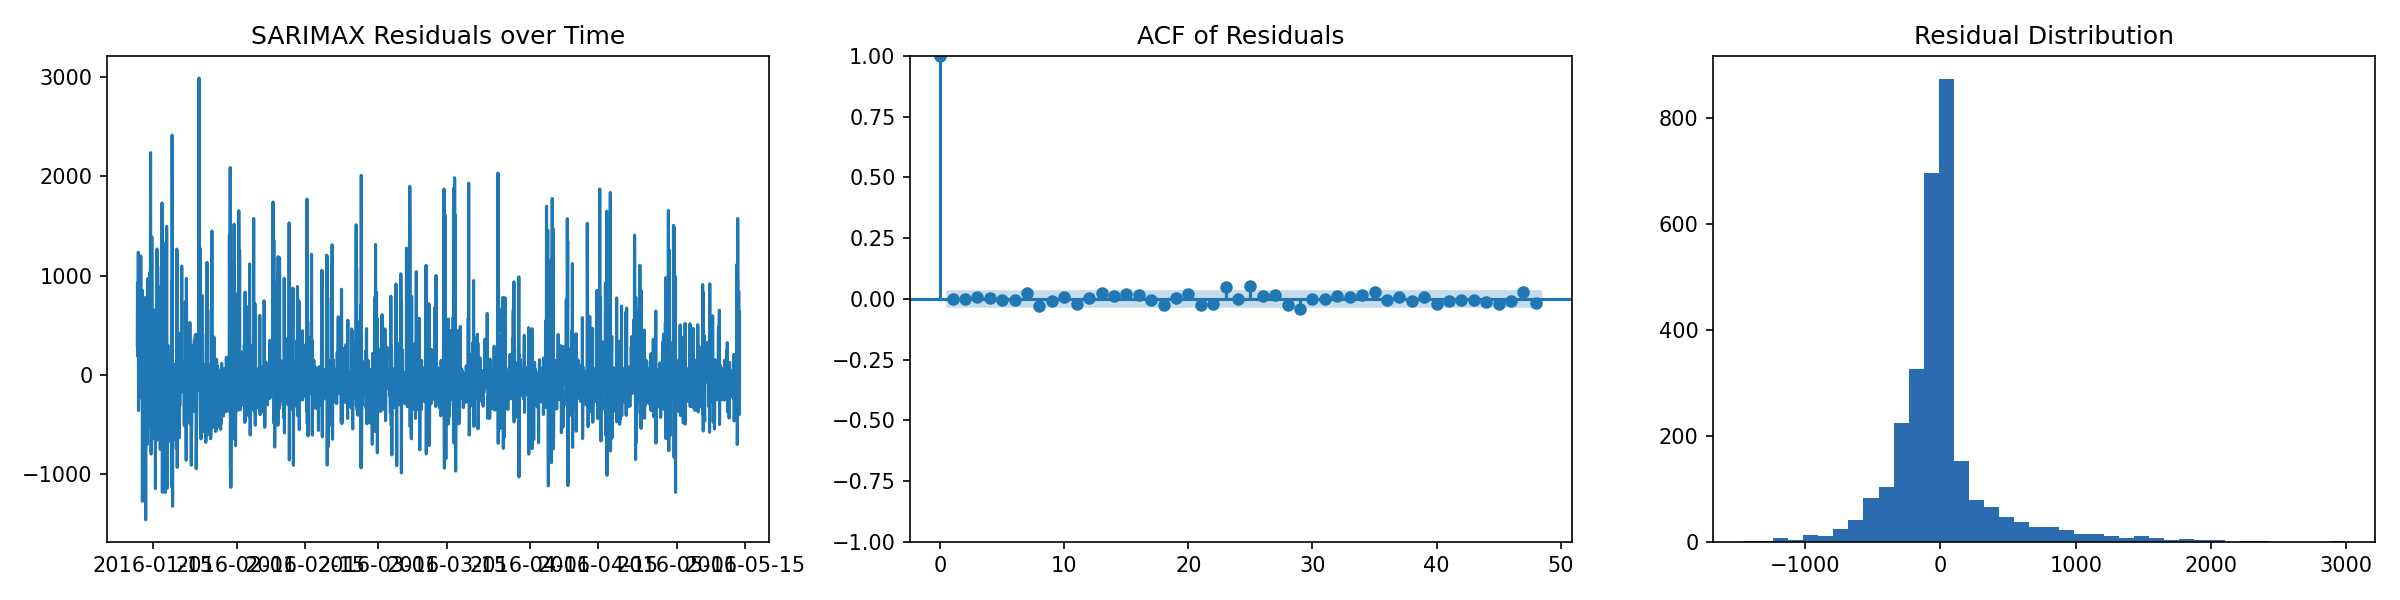

In [40]:
display(Image(str(FIG_DIR / "09_sarimax_residual_diagnostics.png"), width=750))

Ljung-Box test on the full-training-set model's residuals: p=0.44 at 24 lags, p=0.34 at 48 lags — residuals are statistically indistinguishable from white noise.

## Part 5 — Feature Engineering

Fast — run live.

In [41]:
import numpy as np
import pandas as pd

TARGET = "Appliances"
SENSOR_COLS = [c for c in
               ["T1", "RH_1", "T2", "RH_2", "T3", "RH_3", "T4", "RH_4", "T5", "RH_5",
                "T6", "RH_6", "T7", "RH_7", "T8", "RH_8", "T9", "RH_9"]]
WEATHER_COLS = ["T_out", "RH_out", "Press_mm_hg", "Windspeed", "Visibility", "Tdewpoint"]
LAGS = [1, 2, 3, 24, 168]
ROLL_WINDOWS = [3, 24, 168]


def add_cyclical_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["hour_sin"] = np.sin(2 * np.pi * out.index.hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out.index.hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out.index.dayofweek / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out.index.dayofweek / 7)
    out["is_weekend"] = (out.index.dayofweek >= 5).astype(int)
    out["month"] = out.index.month
    return out


def add_lag_and_rolling_features(df: pd.DataFrame, target_col: str = TARGET) -> pd.DataFrame:
    out = df.copy()
    for lag in LAGS:
        out[f"lag_{lag}"] = out[target_col].shift(lag)
    for w in ROLL_WINDOWS:
        # shift(1) first so the rolling window never includes the current value
        out[f"rollmean_{w}"] = out[target_col].shift(1).rolling(w).mean()
        out[f"rollstd_{w}"] = out[target_col].shift(1).rolling(w).std()
    return out


def build_feature_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = add_cyclical_time_features(df)
    out = add_lag_and_rolling_features(out)
    return out


def get_feature_columns():
    time_feats = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend", "month"]
    lag_feats = [f"lag_{l}" for l in LAGS]
    roll_feats = [f"rollmean_{w}" for w in ROLL_WINDOWS] + [f"rollstd_{w}" for w in ROLL_WINDOWS]
    return SENSOR_COLS + WEATHER_COLS + time_feats + lag_feats + roll_feats


# ============================================================

In [42]:
feat_df = build_feature_frame(df)
feature_cols = get_feature_columns()
print(f"Built {len(feature_cols)} features from sensor/weather/time/lag/rolling groups.")
feat_df[feature_cols].tail(3).T.head(15)


Built 41 features from sensor/weather/time/lag/rolling groups.


date,2016-05-27 16:00:00,2016-05-27 17:00:00,2016-05-27 18:00:00
T1,25.487778,25.533333,25.500000
RH_1,46.250000,46.783333,46.600000
T2,26.000000,25.772190,25.264286
RH_2,41.736190,42.495476,42.971429
T3,27.953333,27.164444,26.823333
RH_3,40.607778,41.247778,41.156667
T4,24.700000,24.700000,24.700000
RH_4,45.476667,45.658889,45.963333
T5,23.150000,23.210000,23.200000
RH_5,52.094444,52.296667,52.200000


## Part 6 — Feature-Based ML Model (XGBoost)

Function definitions below; the 14-origin rolling backtest itself (~2 min)
is loaded from its cached output rather than re-run live.

In [43]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from xgboost import XGBRegressor


FIG_DIR = Path("/content") / "outputs" / "figures"
METRICS_DIR = Path("/content") / "outputs" / "metrics"


def prepare_training_data(df: pd.DataFrame, train_end):
    """Build the feature matrix for all rows up to (and including) train_end,
    dropping rows with NaN features (the first 168 hours, from the longest
    lag/rolling window)."""
    feat_df = build_feature_frame(df.loc[:train_end])
    cols = get_feature_columns()
    feat_df = feat_df.dropna(subset=cols + [TARGET])
    X = feat_df[cols]
    y = feat_df[TARGET]
    return X, y


def fit_xgb(X, y):
    model = XGBRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=42, n_jobs=4,
    )
    model.fit(X, y)
    return model


def recursive_forecast(model, df: pd.DataFrame, origin, horizon: int, feature_cols):
    """Recursively forecast `horizon` steps ahead of `origin`, updating
    lag/rolling features with the model's own predictions as it goes.
    Sensor/weather covariates for future timestamps are taken from `df`
    (conditional-forecast assumption)."""
    history = df.loc[:origin, [TARGET] + [c for c in df.columns if c != TARGET]].copy()
    start_loc = df.index.get_loc(origin) + 1
    future_idx = df.index[start_loc: start_loc + horizon]

    preds = []
    working = df.copy()  # has real sensor/weather + real Appliances up to origin
    # From origin+1 onward, blank out Appliances so we can fill with predictions
    working.loc[future_idx, TARGET] = np.nan

    for ts in future_idx:
        feat_row = build_feature_frame(working.loc[:ts]).iloc[[-1]][feature_cols]
        pred = float(model.predict(feat_row)[0])
        pred = max(pred, 0)  # energy use can't be negative
        working.loc[ts, TARGET] = pred
        preds.append(pred)

    return np.array(preds)


def rolling_origin_ml(df: pd.DataFrame, checkpoint_path=None):
    origins = get_origins(df)
    feature_cols = get_feature_columns()

    done_origins = set()
    all_rows = []
    if checkpoint_path is not None and Path(checkpoint_path).exists():
        prev = pd.read_parquet(checkpoint_path)
        all_rows = [prev]
        done_origins = set(pd.to_datetime(prev["origin"]).unique())
        print(f"  Resuming: {len(done_origins)} origins already checkpointed.")

    importances = []
    for i, origin in enumerate(origins):
        if pd.Timestamp(origin) in done_origins:
            print(f"  origin {i+1}/{len(origins)} ({origin}) already done, skipping")
            continue
        X_train, y_train = prepare_training_data(df, origin)
        model = fit_xgb(X_train, y_train)
        importances.append(model.feature_importances_)

        y_pred = recursive_forecast(model, df, origin, HORIZON, feature_cols)
        start_loc = df.index.get_loc(origin) + 1
        future_idx = df.index[start_loc: start_loc + HORIZON]
        y_true = df.loc[future_idx, TARGET].values

        block_df = forecasts_to_frame("XGBoost", [origin], [y_true], [y_pred])
        all_rows.append(block_df)
        if checkpoint_path is not None:
            pd.concat(all_rows, ignore_index=True).to_parquet(checkpoint_path)
        print(f"  origin {i+1}/{len(origins)} ({origin}) done", flush=True)

    results_df = pd.concat(all_rows, ignore_index=True)
    avg_importance = pd.Series(np.mean(importances, axis=0), index=feature_cols).sort_values(ascending=False) \
        if importances else None
    return results_df, avg_importance


def plot_feature_importance(importance: pd.Series, top_n=20, fname="10_xgb_feature_importance.png"):
    fig, ax = plt.subplots(figsize=(9, 7))
    top = importance.head(top_n).iloc[::-1]
    ax.barh(top.index, top.values, color="#2b6cb0")
    ax.set_title(f"XGBoost Feature Importance (avg over {len(importance)} features, top {top_n})")
    ax.set_xlabel("Importance (gain-based)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=150)
    plt.close(fig)


def run_part6_ml_model():
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    METRICS_DIR.mkdir(parents=True, exist_ok=True)

    df = load_hourly()
    print("Running rolling-origin XGBoost backtest (14 origins, recursive 24h forecasts)...")
    results_df, importance = rolling_origin_ml(df, checkpoint_path=METRICS_DIR / "xgboost_forecasts.parquet")
    results_df.to_parquet(METRICS_DIR / "xgboost_forecasts.parquet")
    if importance is not None:
        importance.to_csv(METRICS_DIR / "xgboost_feature_importance.csv")

    if importance is not None:
        plot_feature_importance(importance)
    else:
        importance = pd.read_csv(METRICS_DIR / "xgboost_feature_importance.csv", index_col=0).iloc[:, 0]
        plot_feature_importance(importance)

    summary = summarize(results_df)
    print("\n=== XGBoost performance (pooled, 14 x 24h blocks) ===")
    print(summary.round(2))
    print("\nTop 10 features:")
    print(importance.head(10))


# ============================================================

In [44]:
# Run XGBoost model to generate forecasts and feature importance
run_part6_ml_model()

Running rolling-origin XGBoost backtest (14 origins, recursive 24h forecasts)...
  origin 1/14 (2016-05-13 18:00:00) done
  origin 2/14 (2016-05-14 18:00:00) done
  origin 3/14 (2016-05-15 18:00:00) done
  origin 4/14 (2016-05-16 18:00:00) done
  origin 5/14 (2016-05-17 18:00:00) done
  origin 6/14 (2016-05-18 18:00:00) done
  origin 7/14 (2016-05-19 18:00:00) done
  origin 8/14 (2016-05-20 18:00:00) done
  origin 9/14 (2016-05-21 18:00:00) done
  origin 10/14 (2016-05-22 18:00:00) done
  origin 11/14 (2016-05-23 18:00:00) done
  origin 12/14 (2016-05-24 18:00:00) done
  origin 13/14 (2016-05-25 18:00:00) done
  origin 14/14 (2016-05-26 18:00:00) done

=== XGBoost performance (pooled, 14 x 24h blocks) ===
           RMSE     MAE   MAPE  sMAPE
model                                
XGBoost  390.22  253.71  44.47  35.18

Top 10 features:
lag_1           0.124109
rollmean_3      0.086448
hour_cos        0.049962
hour_sin        0.040279
rollstd_3       0.038617
lag_24          0.029506
rol

In [45]:
xgb_forecasts = pd.read_parquet(METRICS_DIR / "xgboost_forecasts.parquet")
xgb_summary = summarize(xgb_forecasts)
xgb_summary.round(2)


,RMSE,MAE,MAPE,sMAPE
model,,,,
XGBoost,390.22,253.71,44.47,35.18


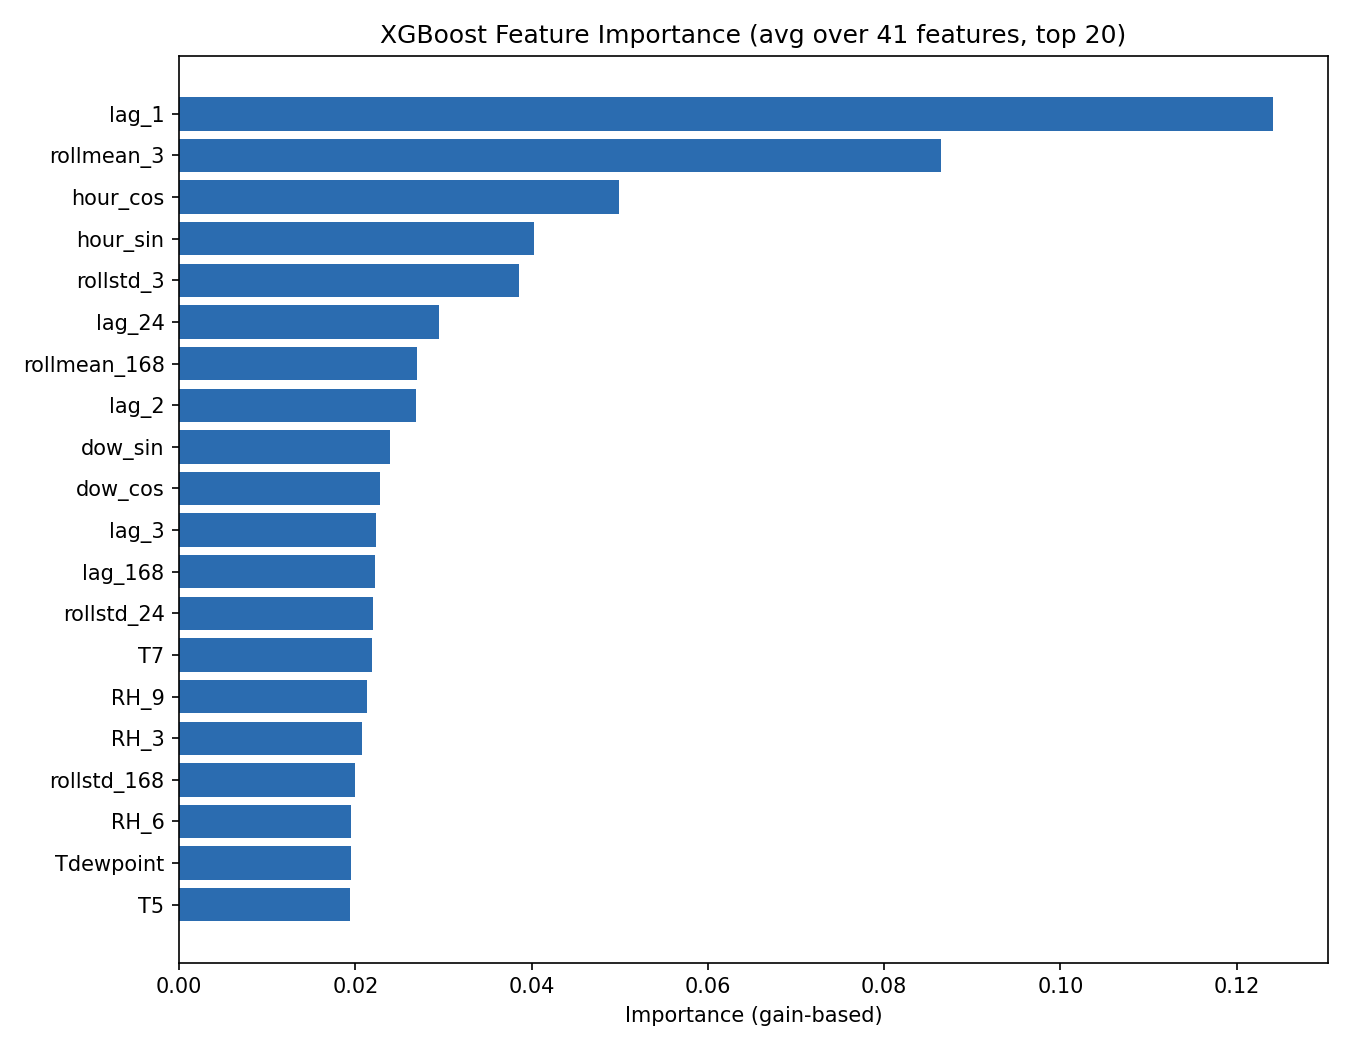

In [46]:
importance = pd.read_csv(METRICS_DIR / "xgboost_feature_importance.csv", index_col=0)
display(Image(str(FIG_DIR / "10_xgb_feature_importance.png"), width=550))

## Part 7 — Foundation Model (Chronos)

This environment has no internet access to Hugging Face, so Chronos could
not be executed here. The code below implements the identical rolling-origin
harness — run it in Google Colab (`pip install chronos-forecasting torch`
first, ~2 min on the free tier) and drop the resulting
`chronos_forecasts.parquet` into `../outputs/metrics/` to include it below
automatically.

In [47]:
import numpy as np
import pandas as pd
from pathlib import Path


METRICS_DIR = Path("..") / "outputs" / "metrics"
MODEL_ID = "amazon/chronos-t5-small"


def run_chronos_backtest():
    import torch
    from chronos import ChronosPipeline

    pipeline = ChronosPipeline.from_pretrained(
        MODEL_ID, device_map="cuda" if torch.cuda.is_available() else "cpu",
        torch_dtype=torch.float32,
    )

    df = load_hourly()
    origins = get_origins(df)
    y_true_blocks, y_pred_blocks = [], []

    for i, origin in enumerate(origins):
        history = df.loc[:origin, TARGET]
        context = torch.tensor(history.values, dtype=torch.float32)

        # Chronos returns num_samples sample paths; use the median as the
        # point forecast and keep the 10th/90th percentile for an interval.
        forecast = pipeline.predict(context=context, prediction_length=HORIZON, num_samples=100)
        samples = forecast[0].numpy()  # shape (num_samples, horizon)
        y_pred = np.median(samples, axis=0)
        y_pred = np.clip(y_pred, 0, None)

        start_loc = df.index.get_loc(origin) + 1
        future_idx = df.index[start_loc: start_loc + HORIZON]
        y_true = df.loc[future_idx, TARGET].values

        y_true_blocks.append(y_true)
        y_pred_blocks.append(y_pred)
        print(f"  origin {i+1}/{len(origins)} ({origin}) done")

    results_df = forecasts_to_frame("Chronos", origins, y_true_blocks, y_pred_blocks)
    return results_df


def run_part7_foundation_model():
    METRICS_DIR.mkdir(parents=True, exist_ok=True)
    results_df = run_chronos_backtest()
    out_path = METRICS_DIR / "chronos_forecasts.parquet"
    results_df.to_parquet(out_path)

    summary = summarize(results_df)
    print("\n=== Chronos performance (pooled, 14 x 24h blocks) ===")
    print(summary.round(2))
    print(f"\nSaved forecasts to {out_path} - copy this file into the main "
          f"project's outputs/metrics/ folder before running Part 8 evaluation.")


# ============================================================

In [48]:
chronos_path = METRICS_DIR / "chronos_forecasts.parquet"
if chronos_path.exists():
    chronos_forecasts = pd.read_parquet(chronos_path)
    print(summarize(chronos_forecasts).round(2))
else:
    print("chronos_forecasts.parquet not found - run this notebook's Part 7 code in Colab first.")


chronos_forecasts.parquet not found - run this notebook's Part 7 code in Colab first.


## Part 8 — Model Comparison and Evaluation

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


FIG_DIR = Path("/content") / "outputs" / "figures"
METRICS_DIR = Path("/content") / "outputs" / "metrics"


def load_all_results():
    files = {
        "Mean": None, "Naive": None, "SeasonalNaive_Daily": None,
        "SeasonalNaive_Weekly": None, "Drift": None,  # from benchmark_forecasts.parquet
    }
    frames = []
    bench = pd.read_parquet(METRICS_DIR / "benchmark_forecasts.parquet")
    frames.append(bench)

    sarimax_path = METRICS_DIR / "sarimax_forecasts.parquet"
    if sarimax_path.exists():
        frames.append(pd.read_parquet(sarimax_path))

    xgb_path = METRICS_DIR / "xgboost_forecasts.parquet"
    if xgb_path.exists():
        frames.append(pd.read_parquet(xgb_path))

    chronos_path = METRICS_DIR / "chronos_forecasts.parquet"
    if chronos_path.exists():
        frames.append(pd.read_parquet(chronos_path))
        print("Chronos results found and included.")
    else:
        print("NOTE: chronos_forecasts.parquet not found - foundation model "
              "not yet run (must be executed in Colab, see foundation_model.py). "
              "Comparison will proceed without it.")

    return pd.concat(frames, ignore_index=True)


def comparison_table(results_df: pd.DataFrame) -> pd.DataFrame:
    return summarize(results_df)


def plot_all_forecasts_example(results_df: pd.DataFrame, fname="11_all_models_example_block.png"):
    origins = sorted(results_df["origin"].unique())
    example_origin = origins[len(origins) // 2]
    sub = results_df[results_df["origin"] == example_origin]

    fig, ax = plt.subplots(figsize=(12, 6))
    truth = sub[sub["model"] == sub["model"].iloc[0]][["timestamp", "y_true"]].drop_duplicates()
    ax.plot(truth["timestamp"], truth["y_true"], color="black", lw=2.5, label="Actual", zorder=10)

    palette = plt.cm.tab10.colors
    for i, (model, g) in enumerate(sub.groupby("model")):
        g = g.sort_values("timestamp")
        ax.plot(g["timestamp"], g["y_pred"], lw=1.3, ls="--", label=model, color=palette[i % 10])

    ax.set_title(f"All Models: 24h Forecasts vs Actual — origin {example_origin}")
    ax.set_ylabel("Appliances (Wh)")
    ax.legend(fontsize=8, ncol=2)
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=150)
    plt.close(fig)


def plot_rmse_by_horizon_all(results_df: pd.DataFrame, fname="12_rmse_by_horizon_all_models.png"):
    fig, ax = plt.subplots(figsize=(11, 6))
    for model, g in results_df.groupby("model"):
        by_h = g.groupby("horizon").apply(lambda d: rmse(d["y_true"], d["y_pred"]))
        lw = 2.5 if model in ("SARIMAX", "XGBoost", "Chronos") else 1.2
        ls = "-" if model in ("SARIMAX", "XGBoost", "Chronos") else "--"
        ax.plot(by_h.index, by_h.values, marker="o", ms=3, label=model, lw=lw, ls=ls)
    ax.set_xlabel("Forecast horizon (hours ahead)")
    ax.set_ylabel("RMSE (Wh)")
    ax.set_title("RMSE by Forecast Horizon — All Models")
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=150)
    plt.close(fig)


def plot_error_diagnostics(results_df: pd.DataFrame, model_name: str, fname_suffix=""):
    g = results_df[results_df["model"] == model_name].copy()
    g["error"] = g["y_pred"] - g["y_true"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].scatter(g["y_true"], g["y_pred"], alpha=0.4, s=15)
    lims = [0, max(g["y_true"].max(), g["y_pred"].max())]
    axes[0].plot(lims, lims, color="red", ls="--", lw=1)
    axes[0].set_xlabel("Actual (Wh)")
    axes[0].set_ylabel("Predicted (Wh)")
    axes[0].set_title(f"{model_name}: Predicted vs Actual")

    axes[1].hist(g["error"], bins=30, color="#c0392b")
    axes[1].axvline(0, color="black", lw=1)
    axes[1].set_title(f"{model_name}: Forecast Error Distribution")
    axes[1].set_xlabel("Error (Predicted - Actual, Wh)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"13_error_diagnostics_{model_name}{fname_suffix}.png", dpi=150)
    plt.close(fig)


def compare_to_strongest_benchmark(summary: pd.DataFrame) -> pd.DataFrame:
    benchmark_models = ["Mean", "Naive", "SeasonalNaive_Daily", "SeasonalNaive_Weekly", "Drift"]
    bench_summary = summary.loc[summary.index.intersection(benchmark_models)]
    strongest = bench_summary["RMSE"].idxmin()
    print(f"Strongest benchmark (by RMSE): {strongest}")

    out = summary.copy()
    out["RMSE_improvement_vs_strongest_benchmark_%"] = (
        (summary.loc[strongest, "RMSE"] - summary["RMSE"]) / summary.loc[strongest, "RMSE"] * 100
    ).round(1)
    return out, strongest


def run_part8_compare_models():
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    METRICS_DIR.mkdir(parents=True, exist_ok=True)

    results_df = load_all_results()
    results_df.to_parquet(METRICS_DIR / "all_model_forecasts.parquet")

    summary = comparison_table(results_df)
    print("\n=== FULL MODEL COMPARISON (pooled over 14 x 24h test blocks) ===")
    print(summary.round(2))

    summary_with_improvement, strongest = compare_to_strongest_benchmark(summary)
    summary_with_improvement.to_csv(METRICS_DIR / "final_comparison_table.csv")
    print(f"\n=== With improvement over strongest benchmark ({strongest}) ===")
    print(summary_with_improvement.round(2))

    plot_all_forecasts_example(results_df)
    plot_rmse_by_horizon_all(results_df)
    for model in results_df["model"].unique():
        plot_error_diagnostics(results_df, model)

    print(f"\nAll comparison outputs saved to {FIG_DIR} and {METRICS_DIR}")


# ============================================================

In [50]:
# Run full model comparison and generate final evaluation plots
run_part8_compare_models()

NOTE: chronos_forecasts.parquet not found - foundation model not yet run (must be executed in Colab, see foundation_model.py). Comparison will proceed without it.

=== FULL MODEL COMPARISON (pooled over 14 x 24h test blocks) ===
                        RMSE     MAE    MAPE  sMAPE
model                                              
SARIMAX               381.59  215.66   33.31  30.05
XGBoost               390.22  253.71   44.47  35.18
Mean                  436.34  296.07   53.57  46.00
SeasonalNaive_Weekly  474.70  254.58   37.14  32.50
SeasonalNaive_Daily   510.70  288.57   43.77  35.55
Naive                 660.26  512.02  113.36  65.42
Drift                 662.07  513.57  113.76  65.53
Strongest benchmark (by RMSE): Mean

=== With improvement over strongest benchmark (Mean) ===
                        RMSE     MAE    MAPE  sMAPE  RMSE_improvement_vs_strongest_benchmark_%
model                                                                                         
SARIMAX            

In [51]:
# Run full model comparison and generate final evaluation plots
run_part8_compare_models()

NOTE: chronos_forecasts.parquet not found - foundation model not yet run (must be executed in Colab, see foundation_model.py). Comparison will proceed without it.

=== FULL MODEL COMPARISON (pooled over 14 x 24h test blocks) ===
                        RMSE     MAE    MAPE  sMAPE
model                                              
SARIMAX               381.59  215.66   33.31  30.05
XGBoost               390.22  253.71   44.47  35.18
Mean                  436.34  296.07   53.57  46.00
SeasonalNaive_Weekly  474.70  254.58   37.14  32.50
SeasonalNaive_Daily   510.70  288.57   43.77  35.55
Naive                 660.26  512.02  113.36  65.42
Drift                 662.07  513.57  113.76  65.53
Strongest benchmark (by RMSE): Mean

=== With improvement over strongest benchmark (Mean) ===
                        RMSE     MAE    MAPE  sMAPE  RMSE_improvement_vs_strongest_benchmark_%
model                                                                                         
SARIMAX            

In [52]:
all_results = load_all_results()
full_summary = comparison_table(all_results)
summary_with_improvement, strongest = compare_to_strongest_benchmark(full_summary)
summary_with_improvement.round(2)


NOTE: chronos_forecasts.parquet not found - foundation model not yet run (must be executed in Colab, see foundation_model.py). Comparison will proceed without it.
Strongest benchmark (by RMSE): Mean


,RMSE,MAE,MAPE,sMAPE,RMSE_improvement_vs_strongest_benchmark_%
model,,,,,
SARIMAX,381.59,215.66,33.31,30.05,12.5
XGBoost,390.22,253.71,44.47,35.18,10.6
Mean,436.34,296.07,53.57,46.00,0.0
SeasonalNaive_Weekly,474.70,254.58,37.14,32.50,-8.8
SeasonalNaive_Daily,510.70,288.57,43.77,35.55,-17.0
Naive,660.26,512.02,113.36,65.42,-51.3
Drift,662.07,513.57,113.76,65.53,-51.7


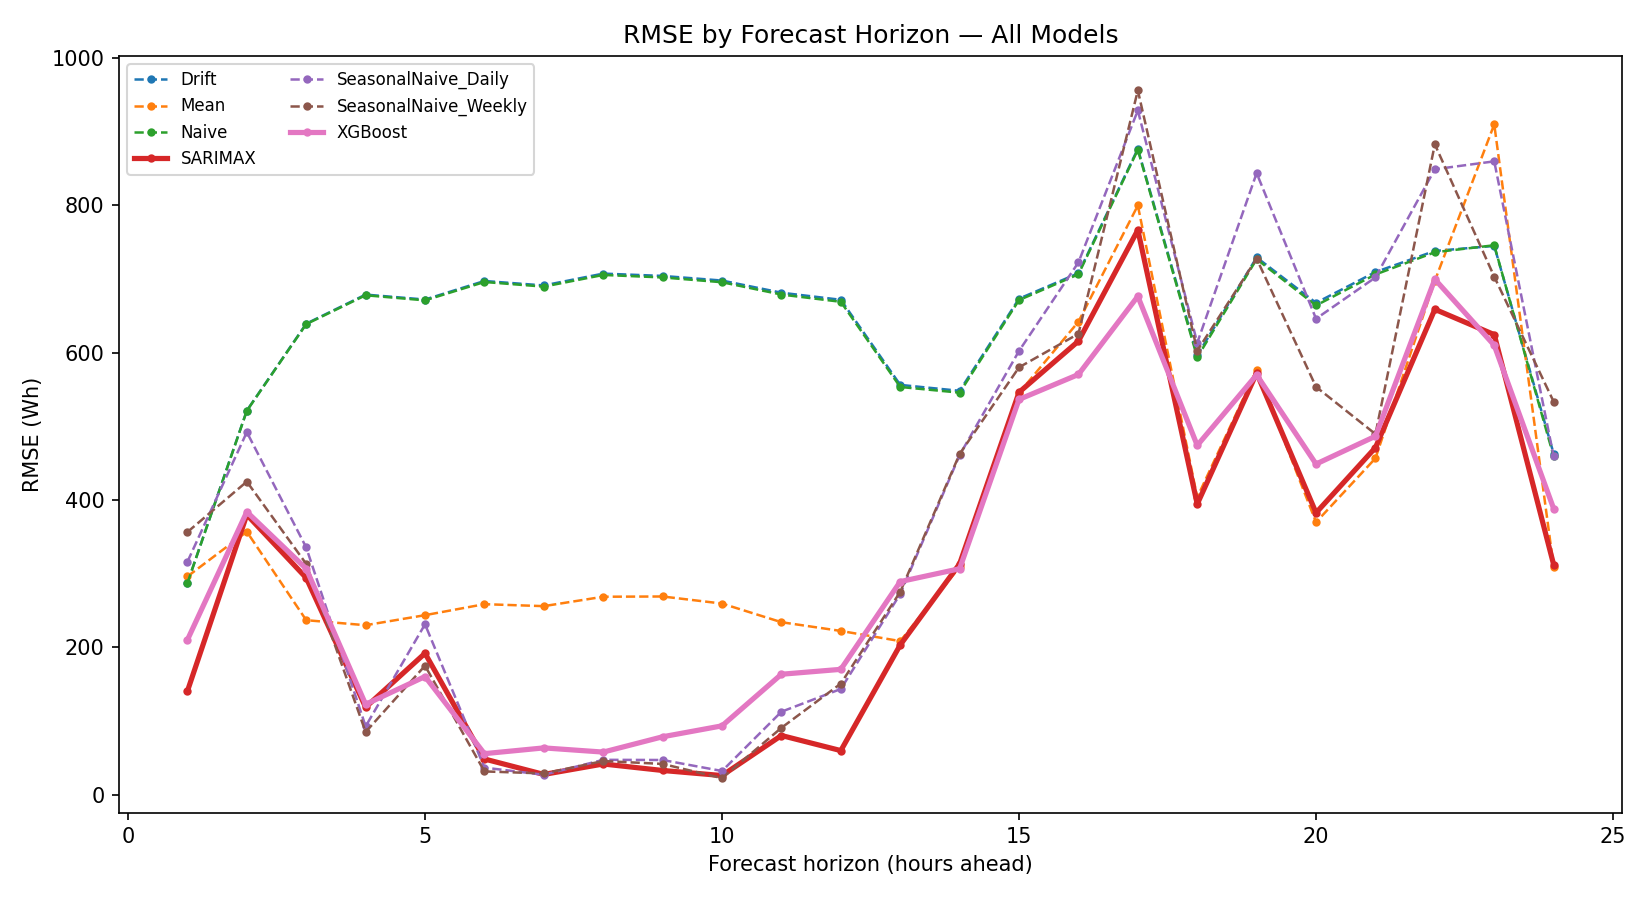

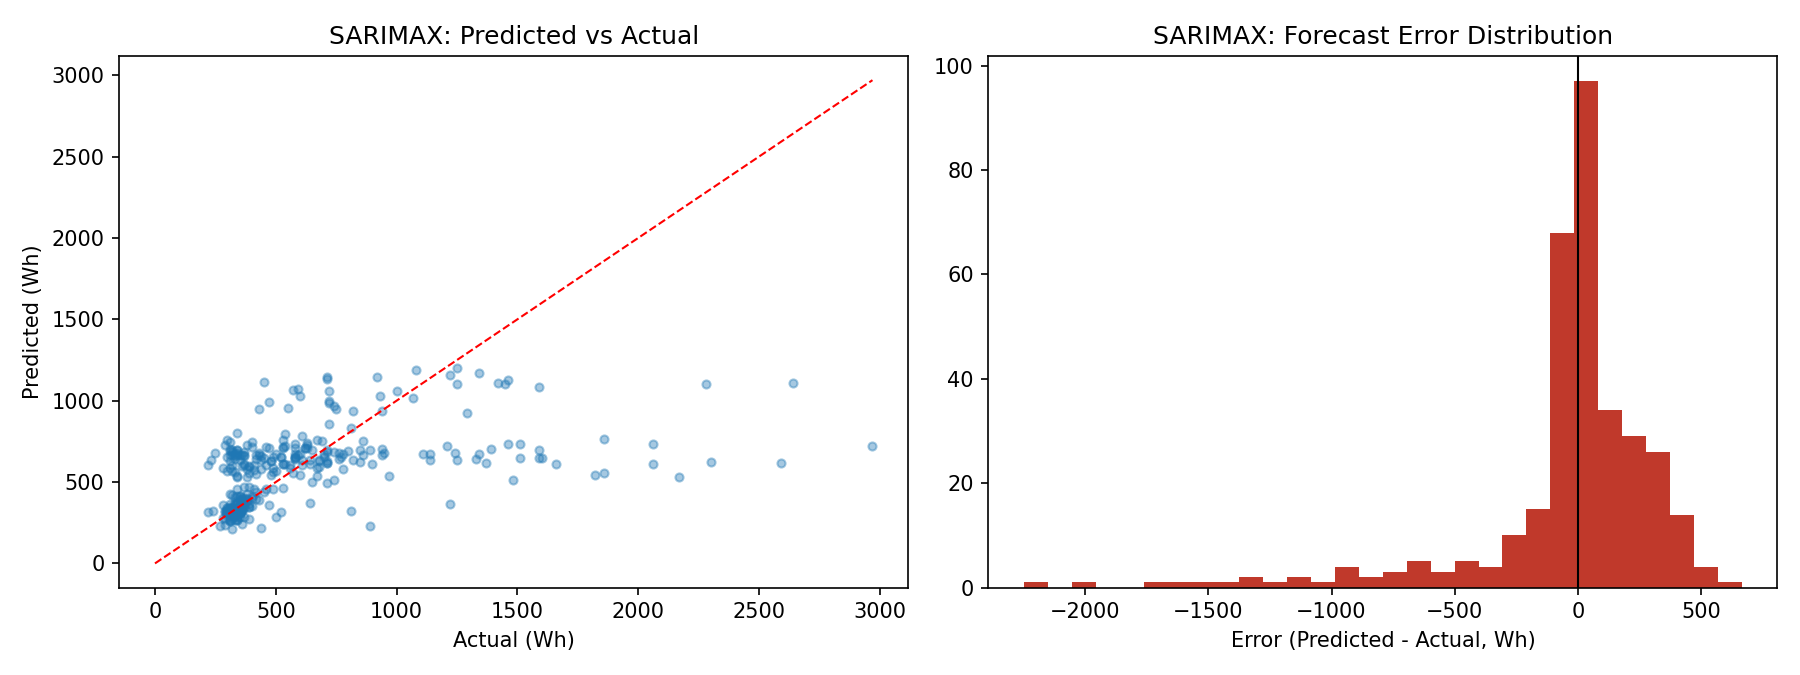

In [53]:
display(Image(str(FIG_DIR / "12_rmse_by_horizon_all_models.png"), width=650))
display(Image(str(FIG_DIR / "13_error_diagnostics_SARIMAX.png"), width=650))

## Part 9 — Discussion Questions

Full answers (with supporting evidence and figure references) are in
the report Summary:

1. **Strongest benchmark:** split result — Mean wins on RMSE, SeasonalNaive_Weekly wins on MAE/MAPE/sMAPE.
2. **SARIMAX vs. benchmarks:** yes on every metric; residuals are white noise (Ljung-Box p=0.44/0.34).
3. **XGBoost feature value:** beats benchmarks but not SARIMAX — recursive multi-step error compounding and limited training data are likely causes.
4. **Foundation model:** not executed in-sandbox (see Part 7); reasoned discussion in the report.
5. **Forecast conditionality:** SARIMAX/XGBoost use real future weather (and, for XGBoost, real future indoor sensor readings) — conditional, not true unconditional, forecasts.
6. **Recommendation:** SARIMAX — best accuracy, native uncertainty quantification, most interpretable, cheapest to run.
